In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [232]:
df = pd.read_csv('00.dataset/Mall_Customers.csv')
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


# 9.Clusstering_DBSCAN_Algorithms

In [233]:
df = df.drop(columns='CustomerID')

In [234]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas")
X_cleaned = preprocessor.fit_transform(df)
X_cleaned.head()

,num__Age,num__Annual Income (k$),num__Spending Score (1-100),cat__Gender_Female,cat__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


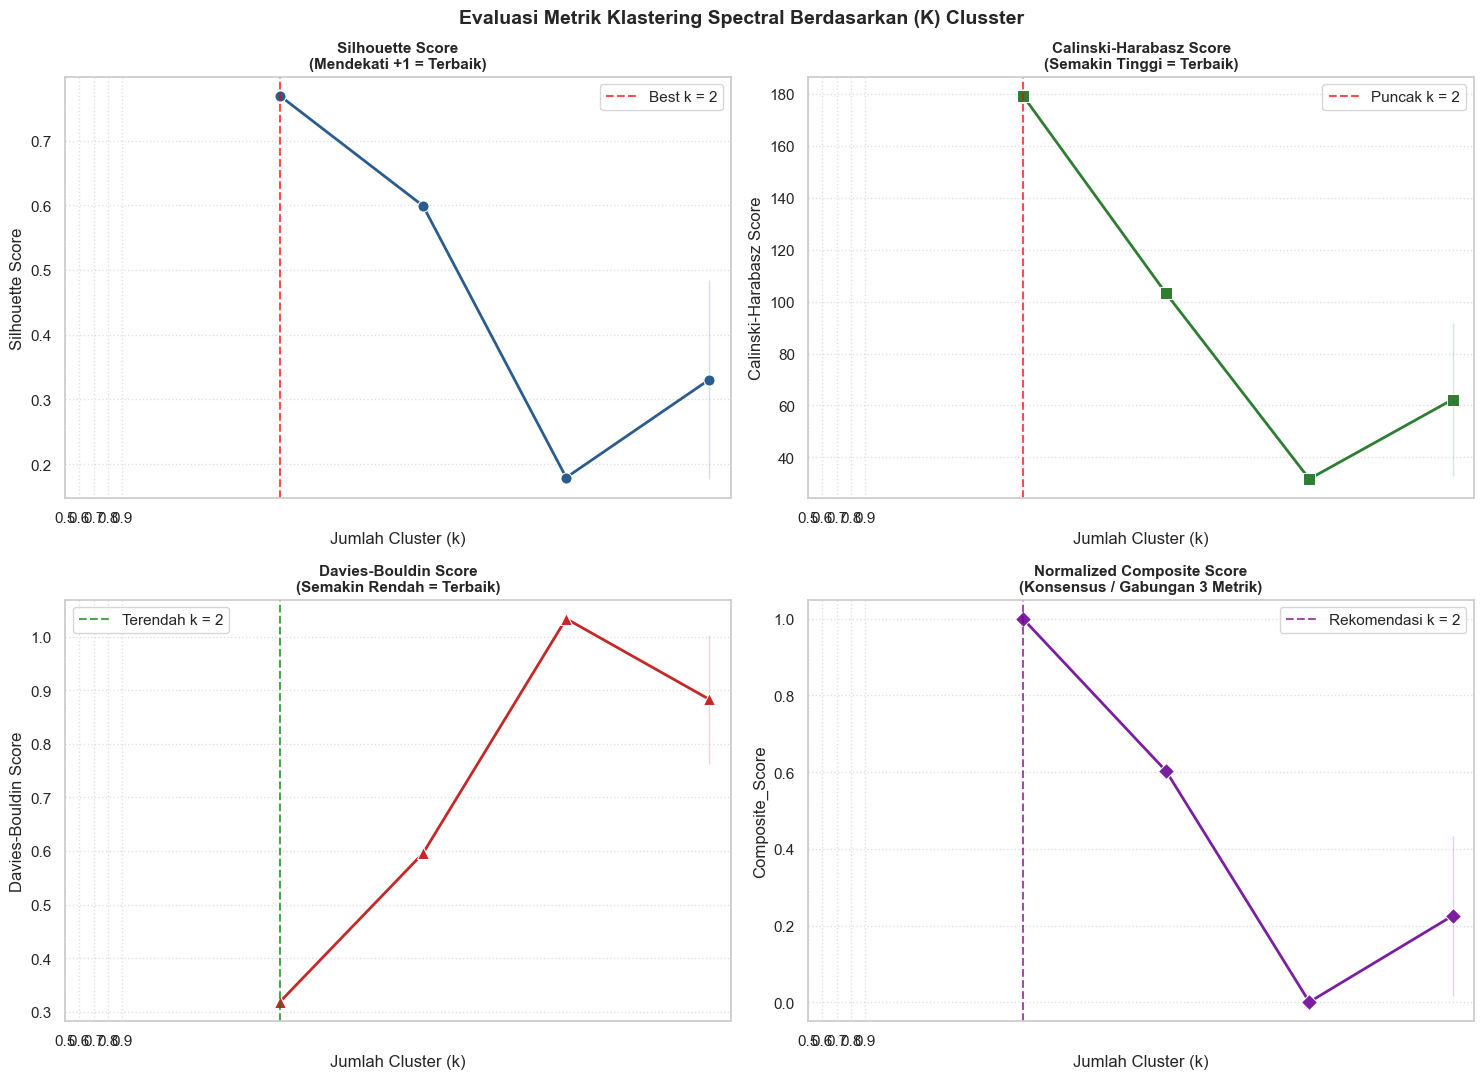

,Clusters Found,eps,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score,Composite_Score
0,2,0.5,0.769415,179.263164,0.318305,1.000000
1,3,0.6,0.599179,103.117539,0.595695,0.602924
2,5,0.7,0.484506,91.841508,0.762680,0.435095
3,4,0.8,0.179162,31.682171,1.033290,0.001282
4,5,0.9,0.176883,32.727962,1.002792,0.016581


In [235]:
eps_range = np.arange(0.1, 1.0, 0.1)  # Menguji nilai eps dari 0.1 hingga 1.5
dim = X_cleaned.shape[1]
min_samples_val = 2 * dim         # Syarat minimal poin dalam cluster

eps_values = []
sil_scores = []
ch_scores = []
db_scores = []
n_clusters_found = []

for eps in eps_range:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples_val)
    labels = dbscan.fit_predict(X_cleaned)
    # Filter titik noise (-1) untuk perhitungan metrik evaluasi
    core_mask = labels != -1
    unique_labels = set(labels[core_mask])
    
    # Metrik hanya bisa dihitung jika terdapat minimal 2 cluster non-noise
    if len(unique_labels) >= 2:
        # Evaluasi hanya pada data non-noise
        X_valid = X_cleaned[core_mask]
        labels_valid = labels[core_mask]
        
        eps_values.append(round(eps, 2))
        sil_scores.append(silhouette_score(X_valid, labels_valid))
        ch_scores.append(calinski_harabasz_score(X_valid, labels_valid))
        db_scores.append(davies_bouldin_score(X_valid, labels_valid))
        n_clusters_found.append(len(unique_labels))

df_scores = pd.DataFrame({
    'Clusters Found': n_clusters_found,
    'eps': eps_values,
    'Silhouette Score': sil_scores,
    'Calinski-Harabasz Score': ch_scores,
    'Davies-Bouldin Score': db_scores
})

scaler = MinMaxScaler()
norm_sil = scaler.fit_transform(df_scores[['Silhouette Score']])
norm_ch = scaler.fit_transform(df_scores[['Calinski-Harabasz Score']])
norm_db = 1 - scaler.fit_transform(df_scores[['Davies-Bouldin Score']])
df_scores['Composite_Score'] = (norm_sil + norm_ch + norm_db) / 3

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- Plot 1: Silhouette Score (Mendekati +1 Lebih Baik) ---
best_k_sil = int(df_scores.loc[df_scores['Silhouette Score'].idxmax(), 'Clusters Found'])
sns.lineplot(ax=axes[0, 0], x='Clusters Found', y='Silhouette Score', data=df_scores, marker='o', markersize=8, linewidth=2, color='#2b5c8f')
axes[0, 0].axvline(x=best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Best k = {best_k_sil}')
axes[0, 0].set_title('Silhouette Score\n(Mendekati +1 = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Cluster (k)')
axes[0, 0].set_xticks(df_scores['eps'])
axes[0, 0].grid(True, linestyle=':', alpha=0.6)
axes[0, 0].legend()

# --- Plot 2: Calinski-Harabasz Score (Makin Tinggi Lebih Baik) ---
best_k_ch = int(df_scores.loc[df_scores['Calinski-Harabasz Score'].idxmax(), 'Clusters Found'])
sns.lineplot(ax=axes[0, 1], x='Clusters Found', y='Calinski-Harabasz Score', data=df_scores, marker='s', markersize=8, linewidth=2, color='#2e7d32')
axes[0, 1].axvline(x=best_k_ch, color='red', linestyle='--', alpha=0.7, label=f'Puncak k = {best_k_ch}')
axes[0, 1].set_title('Calinski-Harabasz Score\n(Semakin Tinggi = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Cluster (k)')
axes[0, 1].set_xticks(df_scores['eps'])
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
axes[0, 1].legend()

# --- Plot 3: Davies-Bouldin Score (Makin Rendah Lebih Baik) ---
best_k_db = int(df_scores.loc[df_scores['Davies-Bouldin Score'].idxmin(), 'Clusters Found'])
sns.lineplot(ax=axes[1, 0], x='Clusters Found', y='Davies-Bouldin Score', data=df_scores, marker='^', markersize=8, linewidth=2, color='#c62828')
axes[1, 0].axvline(x=best_k_db, color='green', linestyle='--', alpha=0.7, label=f'Terendah k = {best_k_db}')
axes[1, 0].set_title('Davies-Bouldin Score\n(Semakin Rendah = Terbaik)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Jumlah Cluster (k)')
axes[1, 0].set_xticks(df_scores['eps'])
axes[1, 0].grid(True, linestyle=':', alpha=0.6)
axes[1, 0].legend()

# --- Plot 4 (BARU): Normalized Composite Score (Gabungan 3 Metrik) ---
best_k_comp = int(df_scores.loc[df_scores['Composite_Score'].idxmax(), 'Clusters Found'])
sns.lineplot(ax=axes[1, 1], x='Clusters Found', y='Composite_Score', data=df_scores, marker='D', markersize=8, linewidth=2, color='#7b1fa2')
axes[1, 1].axvline(x=best_k_comp, color='purple', linestyle='--', alpha=0.7, label=f'Rekomendasi k = {best_k_comp}')
axes[1, 1].set_title('Normalized Composite Score\n(Konsensus / Gabungan 3 Metrik)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Jumlah Cluster (k)')
axes[1, 1].set_xticks(df_scores['eps'])
axes[1, 1].grid(True, linestyle=':', alpha=0.6)
axes[1, 1].legend()

plt.suptitle('Evaluasi Metrik Klastering Spectral Berdasarkan (K) Clusster', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
df_scores

In [236]:
min_samples_val = 2 * dim
epsilon = 0.7
best_dbscan = DBSCAN(eps=epsilon,min_samples=min_samples_val)
df['Cluster'] = best_dbscan.fit_predict(X_cleaned)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,-1
1,Male,21,15,81,-1
2,Female,20,16,6,-1
3,Female,23,16,77,-1
4,Female,31,17,40,-1


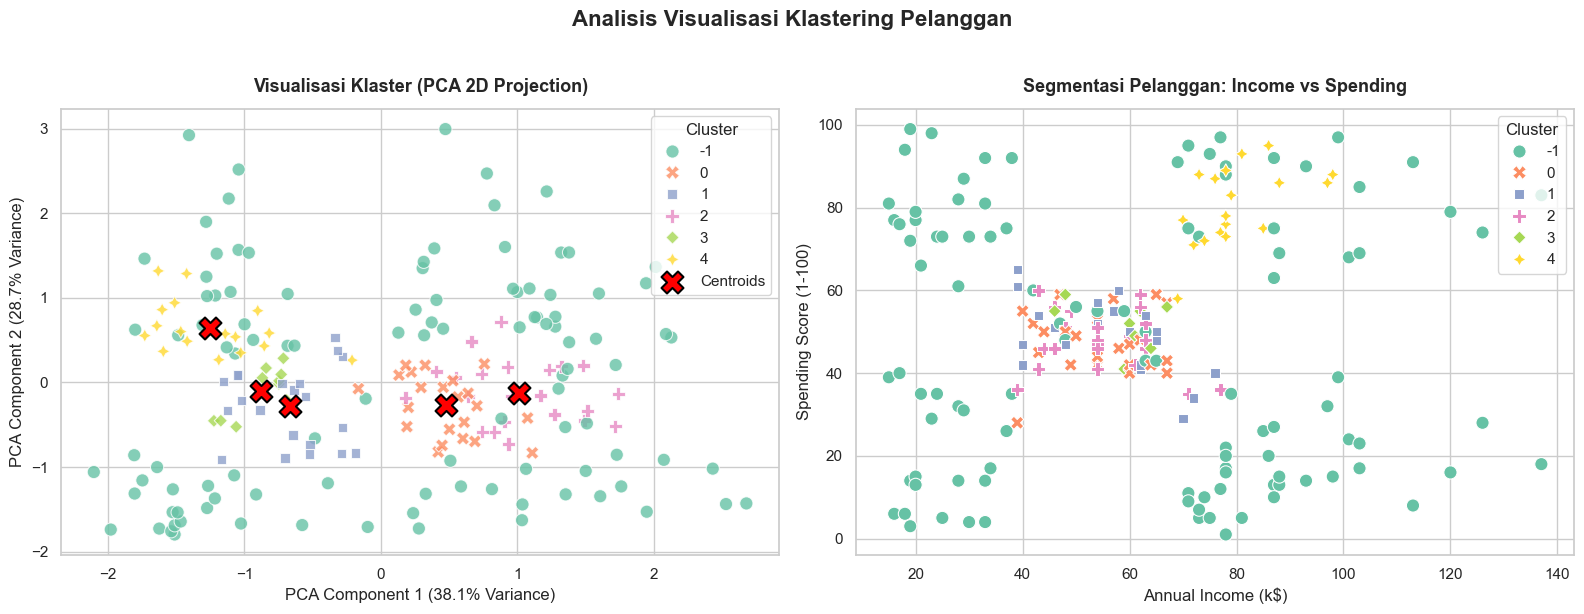

In [237]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cleaned)

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df['Cluster'].values
valid_clusters = df_pca[df_pca['Cluster'] != -1]
centroids_pca = valid_clusters.groupby('Cluster')[['PCA1', 'PCA2']].mean().values

sns.set_theme(style="whitegrid")
palette = 'Set2'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(ax=axes[0],x='PCA1', y='PCA2', hue='Cluster', data=df_pca, palette=palette, s=90, alpha=0.8, style='Cluster')
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=250, c='red', marker='X', edgecolor='black', linewidth=1.5, label='Centroids') # Plot Centroid
axes[0].set_title('Visualisasi Klaster (PCA 2D Projection)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
axes[0].set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
axes[0].legend(title='Cluster', loc='upper right')

sns.scatterplot( ax=axes[1],x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df,  palette=palette, s=90, style='Cluster')
axes[1].set_title('Segmentasi Pelanggan: Income vs Spending', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend(title='Cluster', loc='upper right')

plt.suptitle('Analisis Visualisasi Klastering Pelanggan', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

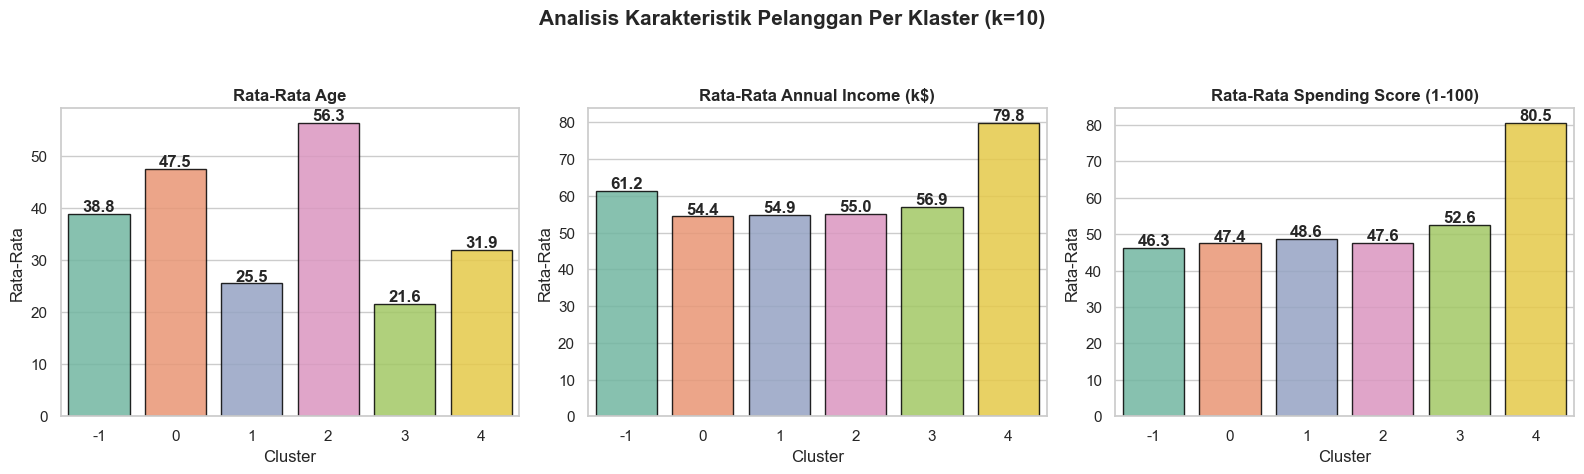

In [238]:
df_profile = df.groupby('Cluster')[num_cols].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(num_cols):
    sns.barplot(ax=axes[i], x='Cluster', y=col, data=df_profile,hue='Cluster',legend=False,palette=palette, edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Rata-Rata {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Rata-Rata')
    for p in axes[i].patches: # Menambahkan label nilai angka di atas bar
        axes[i].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.suptitle(f'Analisis Karakteristik Pelanggan Per Klaster (k={min_samples_val})', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()